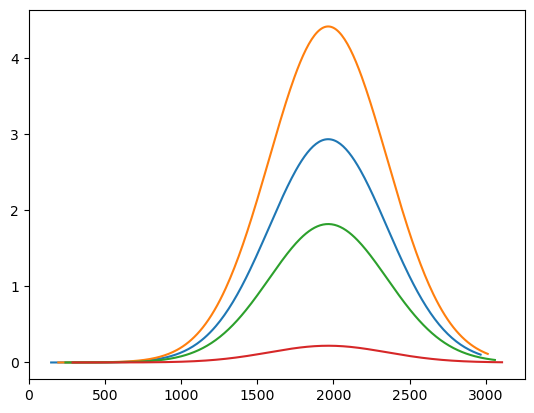

In [5]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob


mass_star = 1.21
r_star = 1.357
teff_star = 6163
nu_max_sun_uHz = 3090.0
teff_sun_K = 5772.0
tau_sun_s = 250
max_rms_amplitude_sun = 2.1
delta_nu_sun = 135.1
epsilon = 1.55
    
def calc_maximum_rms_amplitude_radial(mass_star, teff_star):
    luminosity_ratio = (r_star**2) * (teff_star / teff_sun_K) ** 4
    power = -0.093
    t_red_star = 8907*(luminosity_ratio**power)
    delta_t = 1250
    dwarf_suppression_beta = 1 - np.exp((teff_star - t_red_star)/(delta_t))

    

    max_rms_amplitude_star = max_rms_amplitude_sun * dwarf_suppression_beta * luminosity_ratio *(mass_star**-1) * ((teff_star / teff_sun_K) ** (-2))   
    
    return max_rms_amplitude_star


l = np.linspace(0,3,4)
n = np.linspace(0,300,3001)
V = [1, 1.505, 0.620, 0.075]

    
def calc_nl_rms_amplitude_radial(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    #print(nu_max)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    
    #nu_nl.append(delta_nu * (n + (l/2) + epsilon))
    
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    envelope_FWHM = 0.66 * (nu_max ** 0.88)
    
    if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
                
    width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
        
    nl_rms_ampliude_star = V[l]*(((calc_maximum_rms_amplitude_radial(mass_star, teff_star) ** 2) * np.exp(-((nu_nl - nu_max)**2)/(2*(width_envelope**2))))**0.5)
    
    return nl_rms_ampliude_star, nu_nl

all_freq = []
all_amp = []


def visibility(amp, V):
    amp_visual = []
    for i in freq:
        i = i * V
        amp_visual.append(i)
    return amp_visual


for j in np.arange(len(l)):
    freq = []
    amp = []
    amplitudes_frequency = []
    for i in n:
        amplitudes_frequency.append(calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j))
    
        freq.append(amplitudes_frequency[int(i)][1])
        amp.append(amplitudes_frequency[int(i)][0])
    
    
    
    all_freq.append(freq)
    all_amp.append(amp)
        
    plt.plot(freq,amp)

l_0_freq = all_freq[0]
l_1_freq = all_freq[1]
l_2_freq = all_freq[2]
l_3_freq = all_freq[3]

l_0_amp = all_amp[0]
l_1_amp = all_amp[1]
l_2_amp = all_amp[2]
l_3_amp = all_amp[3]


def width_parameter(mass_star, teff_star, a, b, c):
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    x = a + (b*Teff) + (c*nu_max)
    return x

alpha = width_parameter(mass_star, teff_star, -3.71e0, 1.073e-3, 1.883e-4)
width_alpha = width_parameter(mass_star, teff_star, -7.209e1, 1.543e-2, 9.101e-4)
delta_width_dip = width_parameter(mass_star, teff_star, -2.266e-1, 5.083e-5, 2.715e-6)
nu_dip = width_parameter(mass_star, teff_star, -2.190e3, 4.302e-1, 8.427e-1)
W_dip = width_parameter(mass_star, teff_star, -5.639e-1, 1.138e-4, 1.312e-4)


